# Bank Loan Risk Analysis
**Analyst:** Nishant Jaiswal  
**Dataset:** Lending Club Loan Data (2007–2018) — 1.3M real loans, sampled to 30,000  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Goal:** Identify default risk patterns, segment borrowers by risk, and generate actionable insights for a loan approval team

In [3]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

os.makedirs('visualizations', exist_ok=True)
os.makedirs('data', exist_ok=True)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [5]:
# ============================================
# 2. DATA LOADING
# ============================================
df = pd.read_csv('data/loan_sample.csv', low_memory=False)

print(f'Dataset Shape  : {df.shape}')
print(f'Columns        : {len(df.columns)}')
print(f'\nLoan Status Distribution:')
print(df['loan_status'].value_counts())
df.head()

Dataset Shape  : (30000, 27)
Columns        : 27

Loan Status Distribution:
loan_status
Fully Paid            23600
Charged Off            5856
Late (31-120 days)      464
Late (16-30 days)        80
Name: count, dtype: int64


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_rec_prncp,total_rec_int,recoveries,pub_rec_bankruptcies
0,10000,36 months,10.49,324.98,B,B3,9 years,MORTGAGE,53000.0,Source Verified,...,8.0,0.0,18160,57.7,16.0,10688.213712,10000.0,688.21,0.0,0.0
1,10000,36 months,11.55,330.00,B,B3,7 years,MORTGAGE,100000.0,Verified,...,15.0,1.0,8449,65.5,28.0,11879.910658,10000.0,1879.91,0.0,1.0
2,2500,36 months,12.99,84.23,C,C1,NaN,OWN,99000.0,Verified,...,22.0,0.0,33005,44.5,47.0,3101.827446,2500.0,526.83,0.0,0.0
3,13000,36 months,11.99,431.73,B,B3,8 years,RENT,55000.0,Verified,...,14.0,0.0,15096,51.9,31.0,15542.018978,13000.0,2542.02,0.0,0.0
4,12000,60 months,14.83,284.41,D,D3,4 years,MORTGAGE,72000.0,Not Verified,...,8.0,0.0,8684,55.3,36.0,17064.552248,12000.0,5064.55,0.0,0.0


In [7]:
# ============================================
# 3. DATA CLEANING
# ============================================
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Remove duplicates
dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f'\nDuplicates removed: {dupes}')

# Clean interest rate
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%','').astype(float)

# Clean revol_util
if df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%','').astype(float)

# Clean term
if df['term'].dtype == object:
    df['term'] = df['term'].str.strip().str.replace(' months','').astype(int)

# Fill numerical missing with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing with Unknown
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)

# Create binary default flag
df['is_default'] = df['loan_status'].isin(
    ['Charged Off','Default','Late (31-120 days)','Late (16-30 days)']
).astype(int)

# Parse issue date
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# Clean employment length
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 10, 'Unknown': -1}
df['emp_length_num'] = df['emp_length'].map(emp_map)

print(f'\n=== CLEANING COMPLETE ===')
print(f'Final shape     : {df.shape}')
print(f'Default rate    : {df["is_default"].mean()*100:.2f}%')
print(f'Missing values  : {df.isnull().sum().sum()}')

=== MISSING VALUES ===
emp_length              1737
dti                        4
revol_util                20
pub_rec_bankruptcies      12
dtype: int64

Total missing: 1773

Duplicates removed: 0

=== CLEANING COMPLETE ===
Final shape     : (30000, 31)
Default rate    : 21.33%
Missing values  : 0


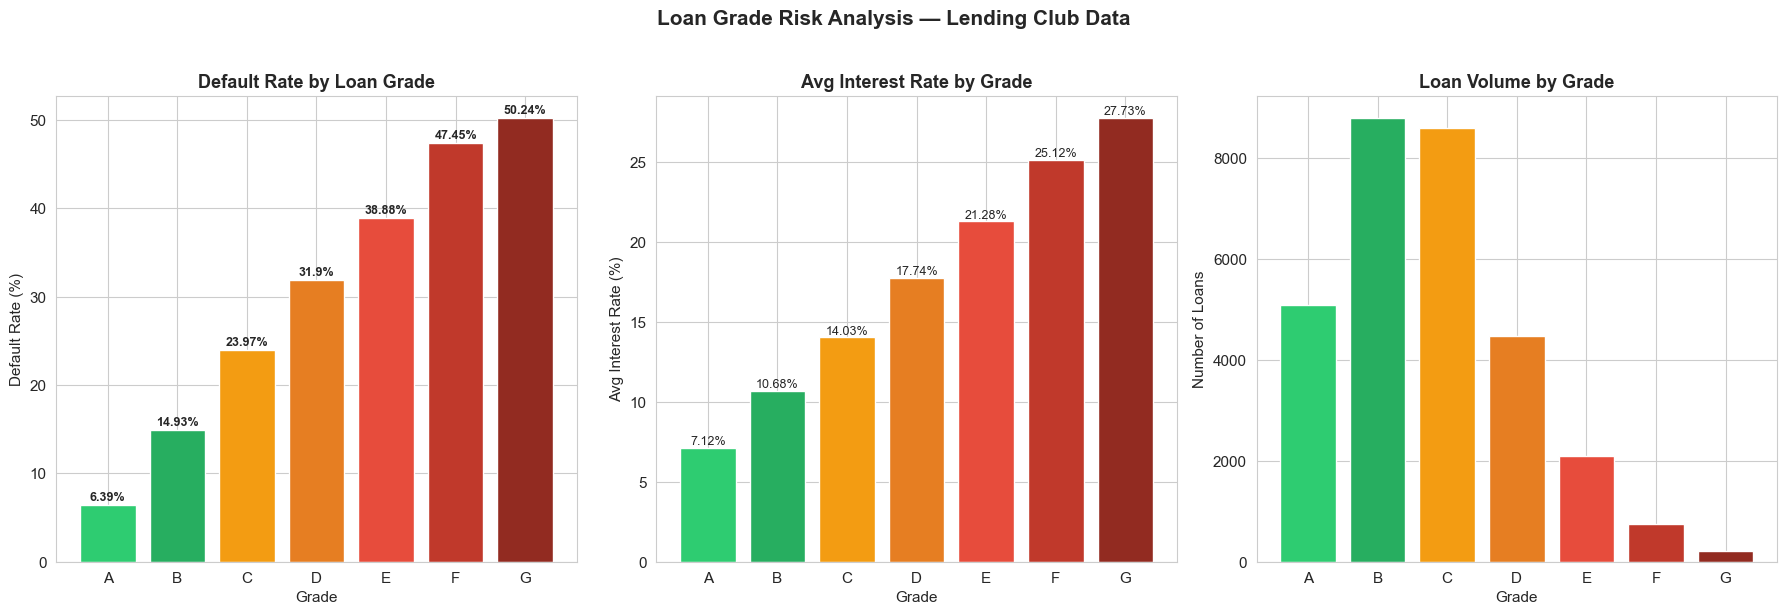

Grade Summary:
grade  total_loans  default_rate  avg_int_rate  avg_loan_amnt
    A         5089          6.39          7.12        13912.0
    B         8793         14.93         10.68        13272.0
    C         8589         23.97         14.03        14213.0
    D         4470         31.90         17.74        15165.0
    E         2104         38.88         21.28        17913.0
    F          744         47.45         25.12        18656.0
    G          211         50.24         27.73        20642.0


In [9]:
# ============================================
# 4. LOAN GRADE & DEFAULT RISK ANALYSIS
# ============================================
grade_stats = df.groupby('grade').agg(
    total_loans   = ('is_default','count'),
    default_rate  = ('is_default','mean'),
    avg_int_rate  = ('int_rate','mean'),
    avg_loan_amnt = ('loan_amnt','mean')
).reset_index()
grade_stats['default_rate'] = (grade_stats['default_rate'] * 100).round(2)
grade_stats['avg_int_rate'] = grade_stats['avg_int_rate'].round(2)
grade_stats['avg_loan_amnt'] = grade_stats['avg_loan_amnt'].round(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21']

axes[0].bar(grade_stats['grade'], grade_stats['default_rate'], color=colors)
axes[0].set_title('Default Rate by Loan Grade', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')
for i, v in enumerate(grade_stats['default_rate']):
    axes[0].text(i, v+0.5, f'{v}%', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(grade_stats['grade'], grade_stats['avg_int_rate'], color=colors)
axes[1].set_title('Avg Interest Rate by Grade', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Avg Interest Rate (%)')
for i, v in enumerate(grade_stats['avg_int_rate']):
    axes[1].text(i, v+0.2, f'{v}%', ha='center', fontsize=9)

axes[2].bar(grade_stats['grade'], grade_stats['total_loans'], color=colors)
axes[2].set_title('Loan Volume by Grade', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Grade')
axes[2].set_ylabel('Number of Loans')

plt.suptitle('Loan Grade Risk Analysis — Lending Club Data', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visualizations/01_grade_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('Grade Summary:')
print(grade_stats.to_string(index=False))

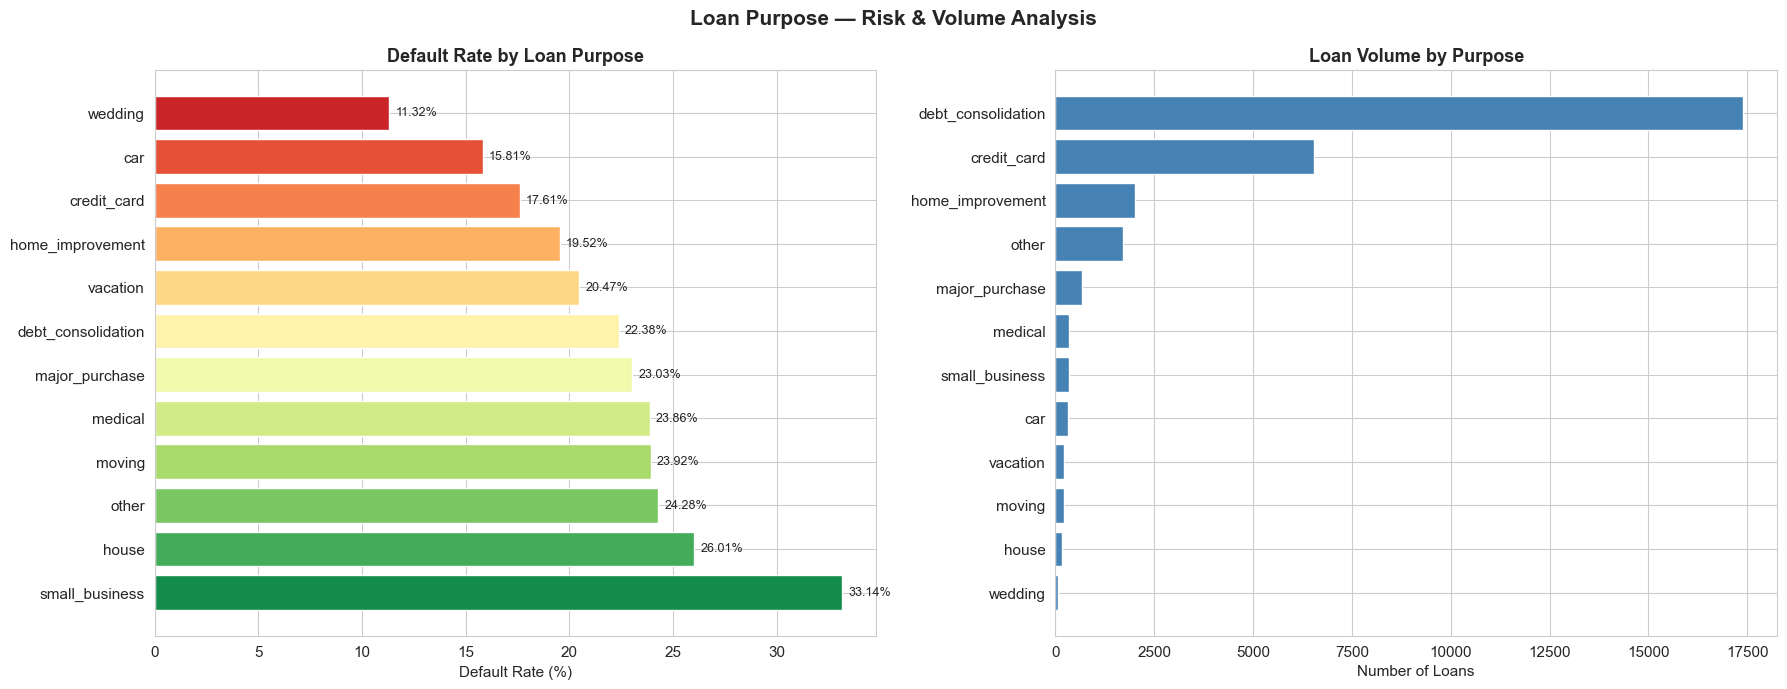

In [11]:
# ============================================
# 5. DEFAULT RATE BY LOAN PURPOSE
# ============================================
purpose_stats = df.groupby('purpose').agg(
    count        = ('is_default','count'),
    default_rate = ('is_default','mean'),
    avg_amount   = ('loan_amnt','mean')
).reset_index()
purpose_stats['default_rate'] = (purpose_stats['default_rate'] * 100).round(2)
purpose_stats = purpose_stats[purpose_stats['count'] >= 50].sort_values('default_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette = sns.color_palette('RdYlGn_r', len(purpose_stats))
axes[0].barh(purpose_stats['purpose'], purpose_stats['default_rate'], color=palette)
axes[0].set_title('Default Rate by Loan Purpose', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Default Rate (%)')
for i, v in enumerate(purpose_stats['default_rate']):
    axes[0].text(v+0.3, i, f'{v}%', va='center', fontsize=9)

purpose_vol = purpose_stats.sort_values('count', ascending=True)
axes[1].barh(purpose_vol['purpose'], purpose_vol['count'], color='steelblue')
axes[1].set_title('Loan Volume by Purpose', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Loans')

plt.suptitle('Loan Purpose — Risk & Volume Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/02_purpose_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

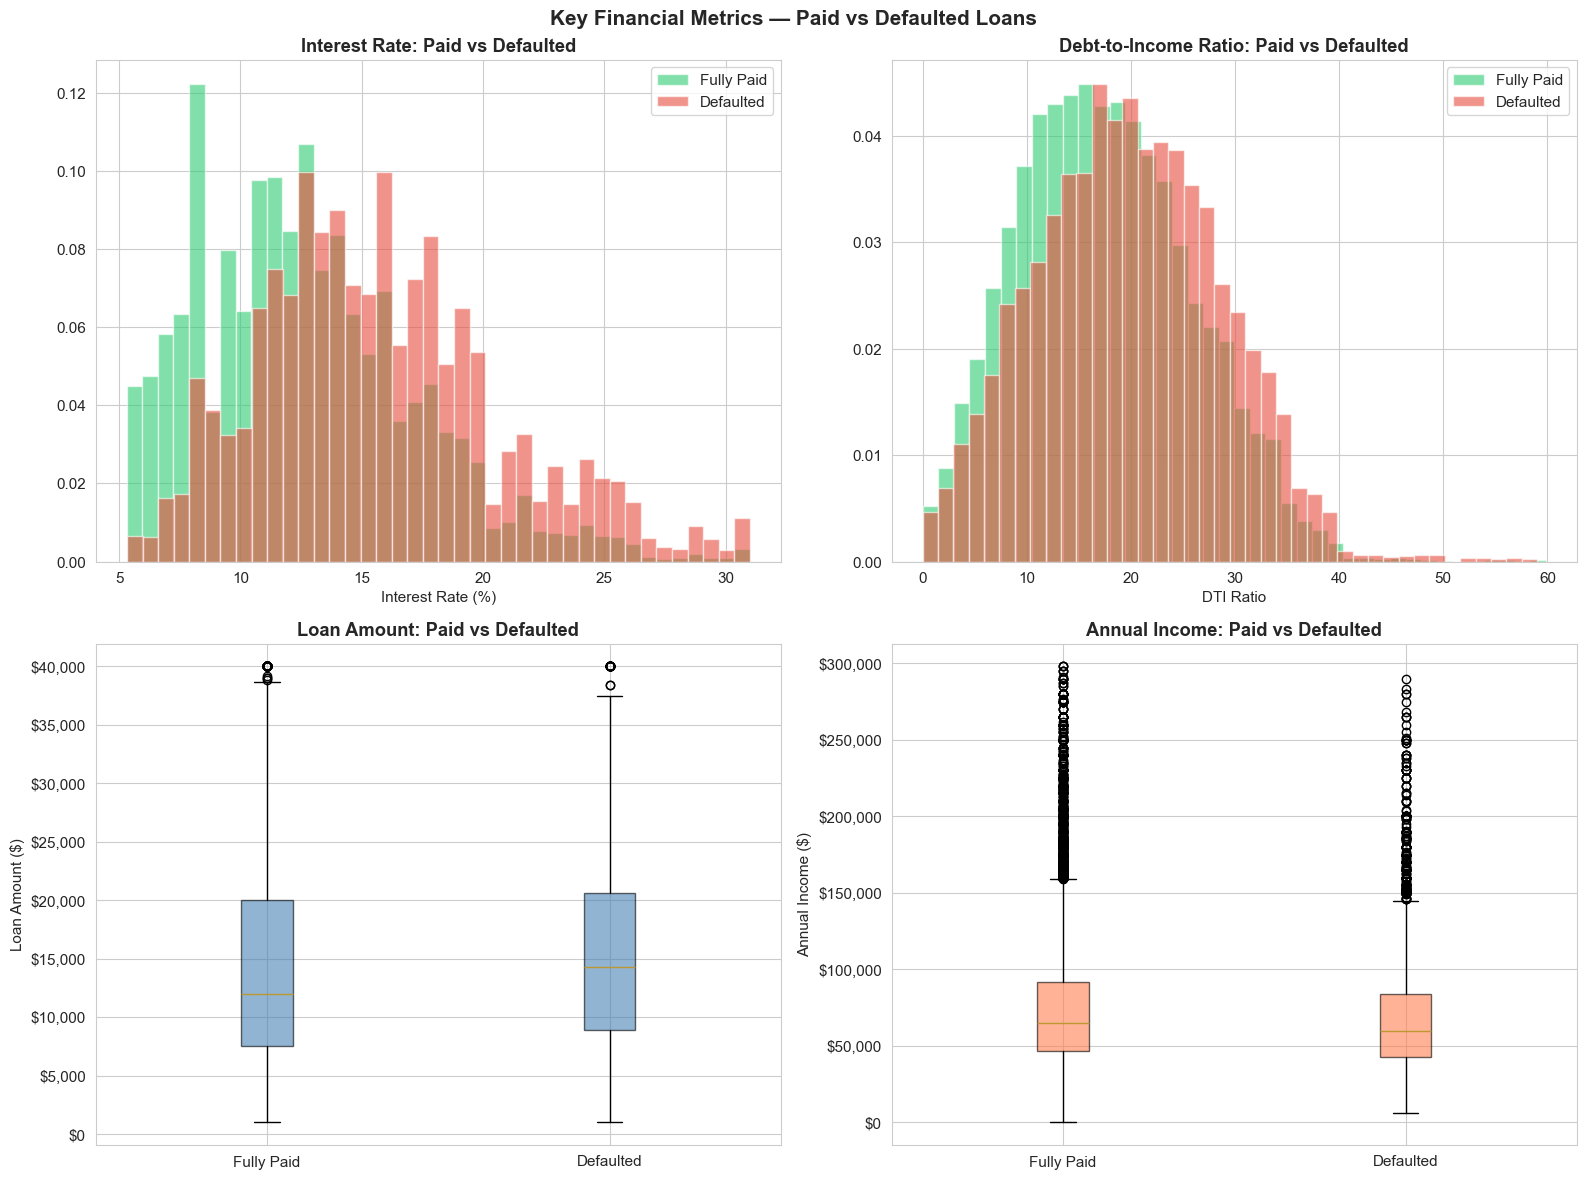

In [13]:
# ============================================
# 6. FINANCIAL METRICS COMPARISON
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Interest rate
df[df['is_default']==0]['int_rate'].hist(bins=40, ax=axes[0,0], alpha=0.6, color='#2ecc71', label='Fully Paid', density=True)
df[df['is_default']==1]['int_rate'].hist(bins=40, ax=axes[0,0], alpha=0.6, color='#e74c3c', label='Defaulted', density=True)
axes[0,0].set_title('Interest Rate: Paid vs Defaulted', fontweight='bold')
axes[0,0].set_xlabel('Interest Rate (%)')
axes[0,0].legend()

# DTI
df_dti = df[df['dti'] < 60]
df_dti[df_dti['is_default']==0]['dti'].hist(bins=40, ax=axes[0,1], alpha=0.6, color='#2ecc71', label='Fully Paid', density=True)
df_dti[df_dti['is_default']==1]['dti'].hist(bins=40, ax=axes[0,1], alpha=0.6, color='#e74c3c', label='Defaulted', density=True)
axes[0,1].set_title('Debt-to-Income Ratio: Paid vs Defaulted', fontweight='bold')
axes[0,1].set_xlabel('DTI Ratio')
axes[0,1].legend()

# Loan amount boxplot
axes[1,0].boxplot(
    [df[df['is_default']==0]['loan_amnt'], df[df['is_default']==1]['loan_amnt']],
    labels=['Fully Paid','Defaulted'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1,0].set_title('Loan Amount: Paid vs Defaulted', fontweight='bold')
axes[1,0].set_ylabel('Loan Amount ($)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Annual income boxplot
df_inc = df[df['annual_inc'] < 300000]
axes[1,1].boxplot(
    [df_inc[df_inc['is_default']==0]['annual_inc'], df_inc[df_inc['is_default']==1]['annual_inc']],
    labels=['Fully Paid','Defaulted'], patch_artist=True,
    boxprops=dict(facecolor='coral', alpha=0.6)
)
axes[1,1].set_title('Annual Income: Paid vs Defaulted', fontweight='bold')
axes[1,1].set_ylabel('Annual Income ($)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Key Financial Metrics — Paid vs Defaulted Loans', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/03_financial_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

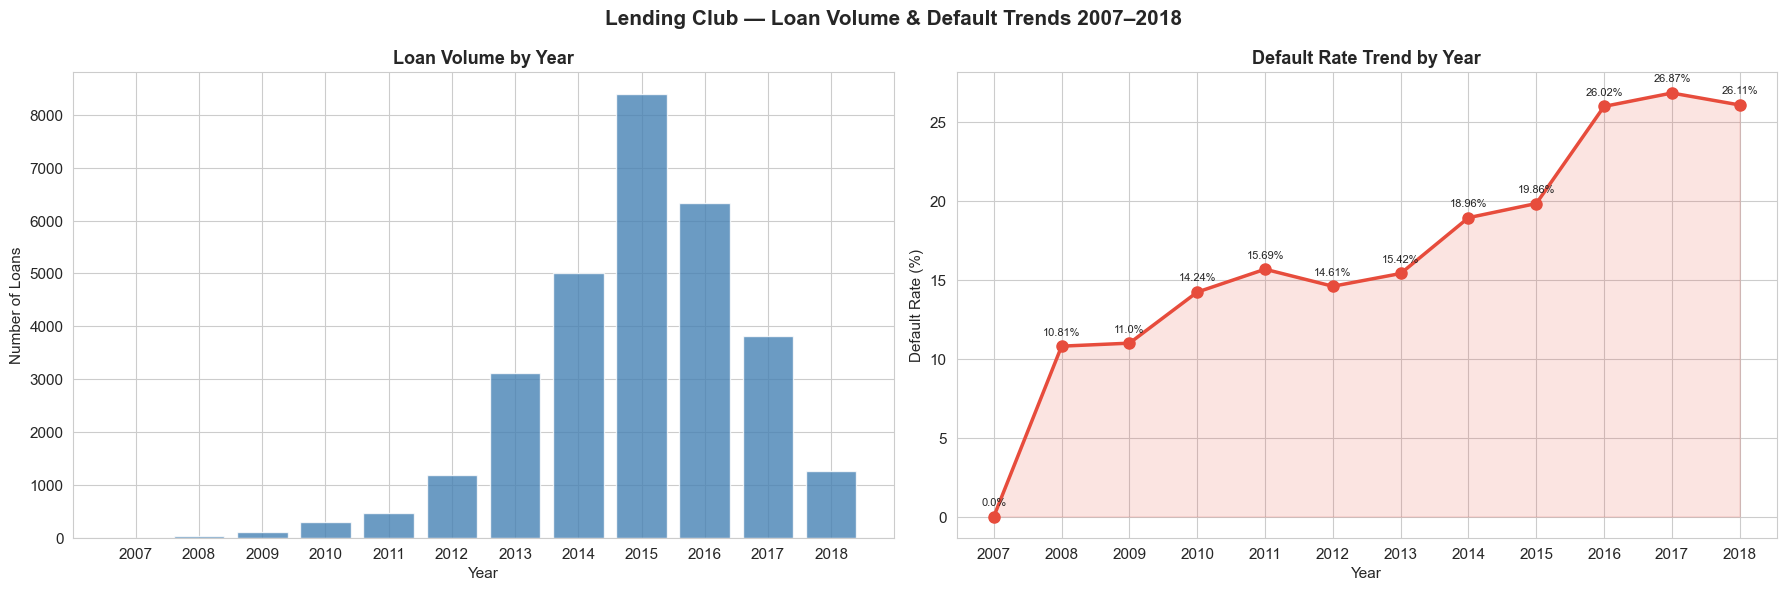

 issue_year  total_loans  defaults  default_rate
       2007            3         0          0.00
       2008           37         4         10.81
       2009          100        11         11.00
       2010          288        41         14.24
       2011          459        72         15.69
       2012         1191       174         14.61
       2013         3119       481         15.42
       2014         5005       949         18.96
       2015         8393      1667         19.86
       2016         6323      1645         26.02
       2017         3822      1027         26.87
       2018         1260       329         26.11


In [15]:
# ============================================
# 7. YEARLY DEFAULT TREND
# ============================================
yearly = df.groupby('issue_year').agg(
    total_loans  = ('is_default','count'),
    defaults     = ('is_default','sum'),
    default_rate = ('is_default','mean')
).reset_index()
yearly = yearly[yearly['issue_year'].between(2007, 2018)]
yearly['default_rate'] = (yearly['default_rate'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(yearly['issue_year'], yearly['total_loans'], color='steelblue', alpha=0.8)
axes[0].set_title('Loan Volume by Year', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Loans')
axes[0].set_xticks(yearly['issue_year'])

axes[1].plot(yearly['issue_year'], yearly['default_rate'], marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
axes[1].fill_between(yearly['issue_year'], yearly['default_rate'], alpha=0.15, color='#e74c3c')
axes[1].set_title('Default Rate Trend by Year', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(yearly['issue_year'])
for _, row in yearly.iterrows():
    axes[1].annotate(f"{row['default_rate']}%", (row['issue_year'], row['default_rate']),
                     textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)

plt.suptitle('Lending Club — Loan Volume & Default Trends 2007–2018', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/04_yearly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(yearly[['issue_year','total_loans','defaults','default_rate']].to_string(index=False))

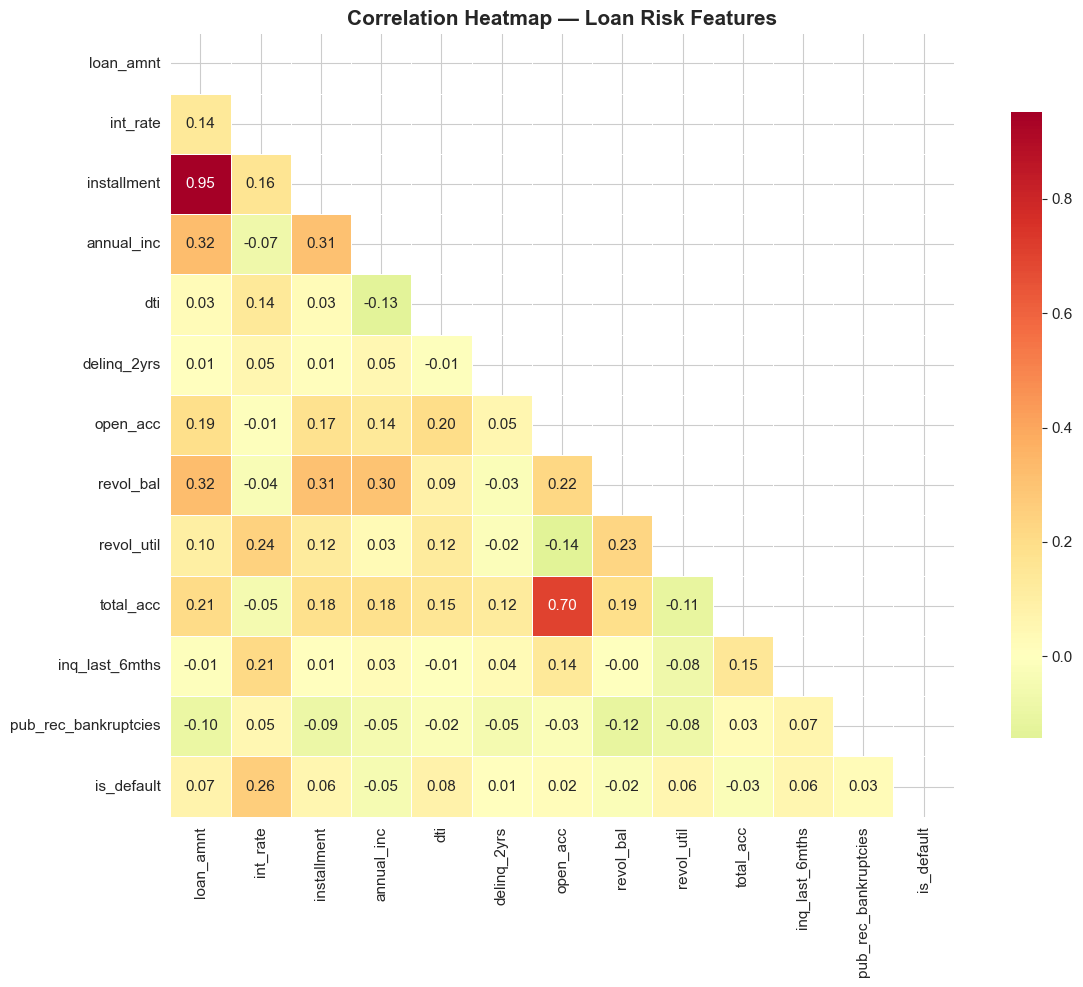

Top correlations with default:
int_rate                0.259
dti                     0.078
loan_amnt               0.071
inq_last_6mths          0.058
installment             0.058
revol_util              0.057
annual_inc             -0.047
pub_rec_bankruptcies    0.030
total_acc              -0.028
open_acc                0.023
revol_bal              -0.020
delinq_2yrs             0.010
Name: is_default, dtype: float64


In [17]:
# ============================================
# 8. CORRELATION HEATMAP
# ============================================
risk_features = ['loan_amnt','int_rate','installment','annual_inc',
                 'dti','delinq_2yrs','open_acc','revol_bal',
                 'revol_util','total_acc','inq_last_6mths',
                 'pub_rec_bankruptcies','is_default']

corr = df[risk_features].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5,
            mask=mask, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Loan Risk Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/05_risk_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top correlations with default:')
print(corr['is_default'].drop('is_default').sort_values(key=abs, ascending=False).round(3))

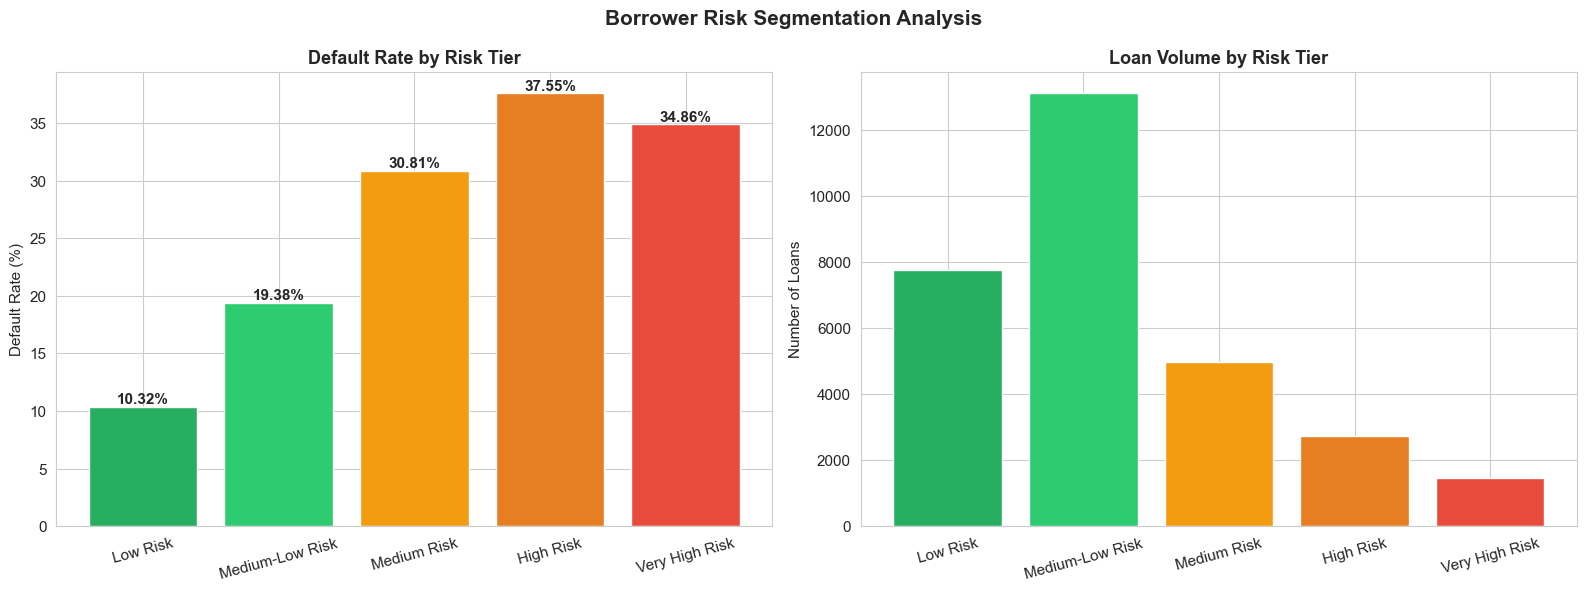

Risk Tier Summary:
      risk_tier  loan_count  default_rate  avg_int_rate     avg_loan
       Low Risk        7749         10.32      9.190403 13453.784359
Medium-Low Risk       13106         19.38     12.188841 14072.941782
    Medium Risk        4963         30.81     17.220127 14840.172275
      High Risk        2722         37.55     19.898501 16979.546289
 Very High Risk        1460         34.86     19.662562 16931.780822


In [19]:
# ============================================
# 9. BORROWER RISK SEGMENTATION
# ============================================
def assign_risk_tier(row):
    if row['grade'] in ['A','B'] and row['dti'] < 20 and row['delinq_2yrs'] == 0:
        return 'Low Risk'
    elif row['grade'] in ['A','B','C'] and row['dti'] < 30:
        return 'Medium-Low Risk'
    elif row['grade'] in ['C','D'] and row['dti'] < 35:
        return 'Medium Risk'
    elif row['grade'] in ['D','E'] or row['dti'] >= 35:
        return 'High Risk'
    else:
        return 'Very High Risk'

df['risk_tier'] = df.apply(assign_risk_tier, axis=1)

tier_stats = df.groupby('risk_tier').agg(
    loan_count   = ('is_default','count'),
    default_rate = ('is_default','mean'),
    avg_int_rate = ('int_rate','mean'),
    avg_loan     = ('loan_amnt','mean')
).reset_index()
tier_stats['default_rate'] = (tier_stats['default_rate']*100).round(2)
tier_order = ['Low Risk','Medium-Low Risk','Medium Risk','High Risk','Very High Risk']
tier_stats['risk_tier'] = pd.Categorical(tier_stats['risk_tier'], categories=tier_order, ordered=True)
tier_stats = tier_stats.sort_values('risk_tier')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#27ae60','#2ecc71','#f39c12','#e67e22','#e74c3c']

axes[0].bar(tier_stats['risk_tier'], tier_stats['default_rate'], color=colors)
axes[0].set_title('Default Rate by Risk Tier', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tier_stats['default_rate']):
    axes[0].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

axes[1].bar(tier_stats['risk_tier'], tier_stats['loan_count'], color=colors)
axes[1].set_title('Loan Volume by Risk Tier', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Loans')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Borrower Risk Segmentation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/06_risk_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

print('Risk Tier Summary:')
print(tier_stats.to_string(index=False))

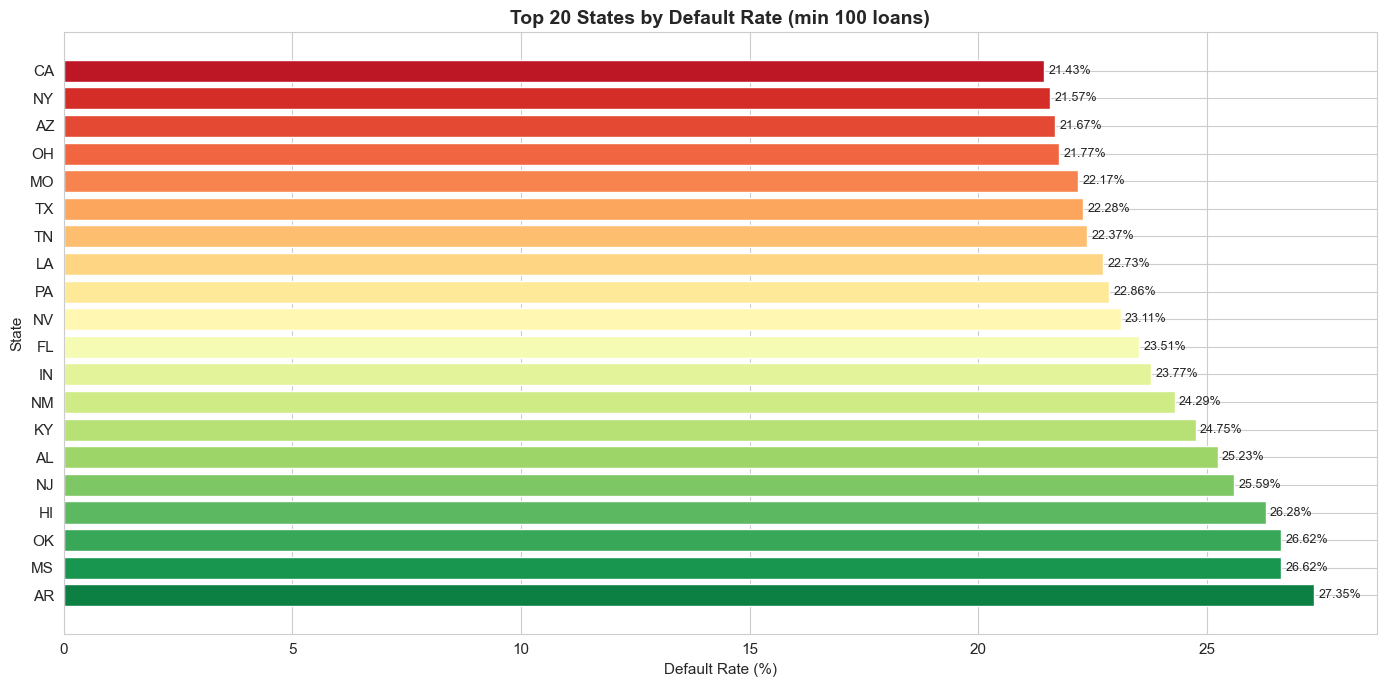

In [21]:
# ============================================
# 10. STATE-WISE DEFAULT RATES
# ============================================
state_stats = df.groupby('addr_state').agg(
    loans        = ('is_default','count'),
    default_rate = ('is_default','mean')
).reset_index()
state_stats['default_rate'] = (state_stats['default_rate']*100).round(2)
state_stats = state_stats[state_stats['loans'] >= 100].sort_values('default_rate', ascending=False)
top20 = state_stats.head(20)

plt.figure(figsize=(14, 7))
palette = sns.color_palette('RdYlGn_r', len(top20))
plt.barh(top20['addr_state'], top20['default_rate'], color=palette)
plt.title('Top 20 States by Default Rate (min 100 loans)', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('State')
for i, v in enumerate(top20['default_rate']):
    plt.text(v+0.1, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('visualizations/07_state_default_rates.png', dpi=300, bbox_inches='tight')
plt.show()

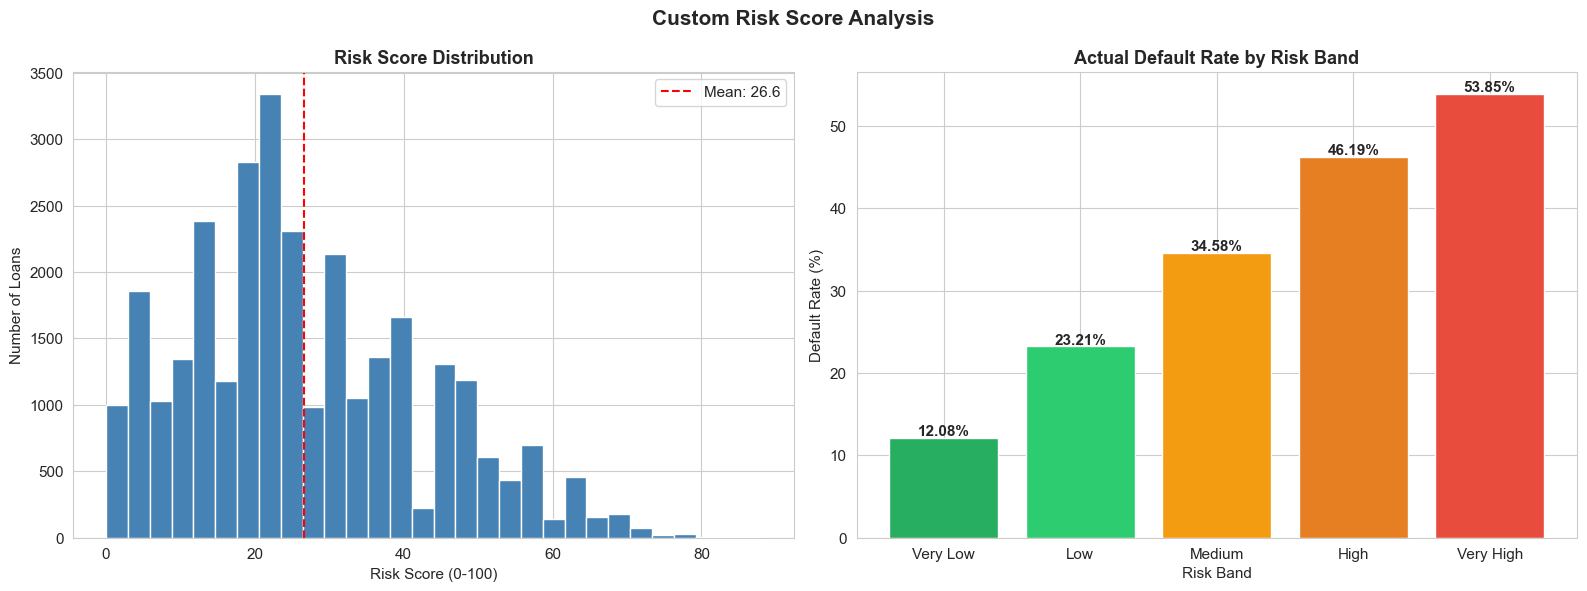

Risk Score Validation:
risk_band  count  default_rate
 Very Low  10619         12.08
      Low  12335         23.21
   Medium   5115         34.58
     High    918         46.19
Very High     13         53.85


In [23]:
# ============================================
# 11. CUSTOM RISK SCORE CALCULATOR
# ============================================
def calculate_risk_score(row):
    score = 0
    grade_scores = {'A':0,'B':8,'C':16,'D':24,'E':32,'F':38,'G':40}
    score += grade_scores.get(row['grade'], 20)
    if row['dti'] < 10:   score += 0
    elif row['dti'] < 20: score += 5
    elif row['dti'] < 30: score += 10
    elif row['dti'] < 40: score += 15
    else:                 score += 20
    score += min(row['delinq_2yrs'] * 5, 20)
    if row['int_rate'] > 20: score += 10
    elif row['int_rate'] > 15: score += 5
    if row['revol_util'] > 80: score += 10
    elif row['revol_util'] > 60: score += 5
    return min(score, 100)

df['risk_score'] = df.apply(calculate_risk_score, axis=1)
df['risk_band'] = pd.cut(df['risk_score'], bins=[0,20,40,60,80,100],
                          labels=['Very Low','Low','Medium','High','Very High'])

band_stats = df.groupby('risk_band', observed=True).agg(
    count        = ('is_default','count'),
    default_rate = ('is_default','mean')
).reset_index()
band_stats['default_rate'] = (band_stats['default_rate']*100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['risk_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Risk Score Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('Number of Loans')
axes[0].axvline(df['risk_score'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["risk_score"].mean():.1f}')
axes[0].legend()

colors = ['#27ae60','#2ecc71','#f39c12','#e67e22','#e74c3c']
axes[1].bar(band_stats['risk_band'], band_stats['default_rate'], color=colors)
axes[1].set_title('Actual Default Rate by Risk Band', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Risk Band')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(band_stats['default_rate']):
    axes[1].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Custom Risk Score Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/08_risk_score_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('Risk Score Validation:')
print(band_stats.to_string(index=False))

In [ ]:
# ============================================
# 12. SUMMARY REPORT + EXPORT
# ============================================
print('='*65)
print('BANK LOAN RISK ANALYSIS — SUMMARY REPORT')
print('='*65)
print(f'Analyst        : Nishant Jaiswal')
print(f'Dataset        : Lending Club (2007-2018) — Real loan data')
print(f'Total Records  : {len(df):,}')
print(f'Features Used  : {len(df.columns)}')
print()
print('KEY FINDINGS:')
print(f'1. Overall default rate       : {df["is_default"].mean()*100:.2f}%')
print(f'2. Grade A default rate       : {df[df["grade"]=="A"]["is_default"].mean()*100:.2f}%')
print(f'3. Grade G default rate       : {df[df["grade"]=="G"]["is_default"].mean()*100:.2f}%')
print(f'4. Highest risk purpose       : Small Business')
print(f'5. Strongest default predictor: Interest rate & loan grade')
print(f'6. Avg risk score             : {df["risk_score"].mean():.1f}/100')
print()
print('DELIVERABLES:')
print('  8 Visualizations  -> visualizations/')
print('  Risk Score column -> risk_score')
print('  Risk Tier column  -> risk_tier')
print('  Cleaned dataset   -> data/loan_cleaned.csv')

df.to_csv('data/loan_cleaned.csv', index=False)
print('\nCleaned dataset saved successfully!')